In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [9]:
import openpyxl

wb = openpyxl.load_workbook('/content/Delinquency_prediction_dataset (1).xlsx')

print(wb.sheetnames)

[]


In [6]:
df= pd.read_excel('/content/Delinquency_prediction_dataset.xlsx')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,39
Credit_Score,2
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,29
Debt_to_Income_Ratio,0
Employment_Status,0


In [ ]:
df.sample(50)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
50,CUST0051,56,169865.0,336.0,0.050000,6,0,92183.0,0.168068,Employed,8,Gold,New York,Missed,Late,On-time,Late,Late,On-time
346,CUST0347,57,117023.0,700.0,0.710611,1,0,89537.0,0.336318,EMP,3,Platinum,Phoenix,On-time,Late,Missed,Missed,Missed,Missed
57,CUST0058,43,107193.0,843.0,0.362736,0,0,70793.0,0.357470,EMP,12,Student,Chicago,Missed,Missed,Missed,Missed,Late,On-time
144,CUST0145,57,NaN,694.0,0.849848,0,0,3494.0,0.280432,Unemployed,7,Student,Phoenix,On-time,Missed,On-time,Missed,Late,On-time
67,CUST0068,52,172164.0,600.0,0.177831,0,0,7468.0,0.485256,Employed,6,Business,Los Angeles,Missed,Missed,On-time,Late,Late,Missed
75,CUST0076,23,181267.0,542.0,0.050000,6,0,24851.0,0.282236,retired,12,Platinum,Chicago,Missed,Missed,Late,Missed,Late,On-time
185,CUST0186,24,68932.0,792.0,0.391480,4,0,84521.0,0.326619,Self-employed,14,Gold,Chicago,On-time,On-time,Missed,Late,Late,On-time
56,CUST0057,26,76629.0,673.0,0.662659,3,0,35372.0,0.314209,Employed,3,Student,Chicago,On-time,Late,Late,Late,Missed,On-time
247,CUST0248,19,102235.0,412.0,0.541005,2,1,26649.0,0.464228,Self-employed,13,Platinum,Phoenix,On-time,Late,On-time,On-time,On-time,Late
396,CUST0397,45,183152.0,656.0,0.305193,4,0,24835.0,0.133071,retired,2,Standard,Los Angeles,On-time,Late,On-time,Missed,On-time,Late


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Delinquent_Account'].value_counts()

,count
Delinquent_Account,
0,420
1,80


In [ ]:
df.groupby('Employment_Status')['Delinquent_Account'].mean()

,Delinquent_Account
Employment_Status,
EMP,0.148148
Employed,0.182927
Self-employed,0.162500
Unemployed,0.193548
employed,0.155844
retired,0.114943


In [ ]:
df.corr(numeric_only=True)

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
Age,1.000000,0.006496,-0.034075,0.015811,-0.023511,0.022508,-0.051190,-0.007883,0.016942
Income,0.006496,1.000000,0.071287,0.041181,-0.004696,0.045409,-0.051285,-0.064181,-0.004901
Credit_Score,-0.034075,0.071287,1.000000,-0.021550,-0.014842,0.034833,-0.015618,-0.005362,-0.036904
Credit_Utilization,0.015811,0.041181,-0.021550,1.000000,0.019666,0.034224,-0.051119,-0.064661,0.065264
Missed_Payments,-0.023511,-0.004696,-0.014842,0.019666,1.000000,-0.026478,-0.015548,0.000148,-0.097345
Delinquent_Account,0.022508,0.045409,0.034833,0.034224,-0.026478,1.000000,-0.004320,0.034386,-0.039829
Loan_Balance,-0.051190,-0.051285,-0.015618,-0.051119,-0.015548,-0.004320,1.000000,0.056971,0.054607
Debt_to_Income_Ratio,-0.007883,-0.064181,-0.005362,-0.064661,0.000148,0.034386,0.056971,1.000000,0.026144
Account_Tenure,0.016942,-0.004901,-0.036904,0.065264,-0.097345,-0.039829,0.054607,0.026144,1.000000


In [ ]:
(df.isnull().sum()/len(df))*100

,0
Customer_ID,0.0
Age,0.0
Income,7.8
Credit_Score,0.4
Credit_Utilization,0.0
Missed_Payments,0.0
Delinquent_Account,0.0
Loan_Balance,5.8
Debt_to_Income_Ratio,0.0
Employment_Status,0.0


In [ ]:
df['Delinquent_Account'].value_counts(normalize=True)*100

,proportion
Delinquent_Account,
0,84.0
1,16.0


In [ ]:
df.groupby('Delinquent_Account')['Missed_Payments'].mean()

,Missed_Payments
Delinquent_Account,
0,2.990476
1,2.850000


In [ ]:
df.groupby('Delinquent_Account')['Credit_Utilization'].mean()

,Credit_Utilization
Delinquent_Account,
0,0.488505
1,0.506887


In [ ]:
df.groupby('Delinquent_Account')['Credit_Score'].mean()

,Credit_Score
Delinquent_Account,
0,575.145933
1,591.150000


In [ ]:
df.groupby('Delinquent_Account')['Debt_to_Income_Ratio'].mean()

,Debt_to_Income_Ratio
Delinquent_Account,
0,0.297445
1,0.306301


In [ ]:
corr=df.corr(numeric_only=True)

corr

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
Age,1.000000,0.006496,-0.034075,0.015811,-0.023511,0.022508,-0.051190,-0.007883,0.016942
Income,0.006496,1.000000,0.071287,0.041181,-0.004696,0.045409,-0.051285,-0.064181,-0.004901
Credit_Score,-0.034075,0.071287,1.000000,-0.021550,-0.014842,0.034833,-0.015618,-0.005362,-0.036904
Credit_Utilization,0.015811,0.041181,-0.021550,1.000000,0.019666,0.034224,-0.051119,-0.064661,0.065264
Missed_Payments,-0.023511,-0.004696,-0.014842,0.019666,1.000000,-0.026478,-0.015548,0.000148,-0.097345
Delinquent_Account,0.022508,0.045409,0.034833,0.034224,-0.026478,1.000000,-0.004320,0.034386,-0.039829
Loan_Balance,-0.051190,-0.051285,-0.015618,-0.051119,-0.015548,-0.004320,1.000000,0.056971,0.054607
Debt_to_Income_Ratio,-0.007883,-0.064181,-0.005362,-0.064661,0.000148,0.034386,0.056971,1.000000,0.026144
Account_Tenure,0.016942,-0.004901,-0.036904,0.065264,-0.097345,-0.039829,0.054607,0.026144,1.000000


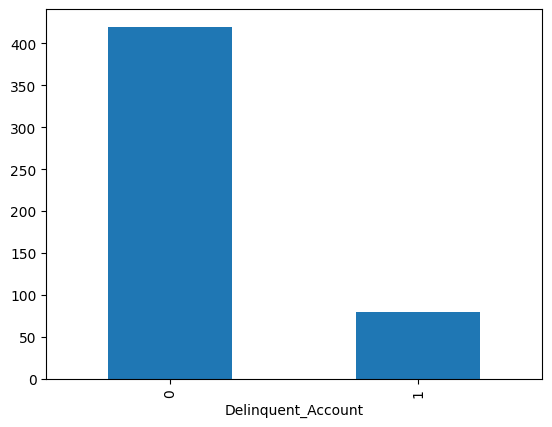

In [ ]:
df['Delinquent_Account'].value_counts().plot(kind='bar')
plt.show()

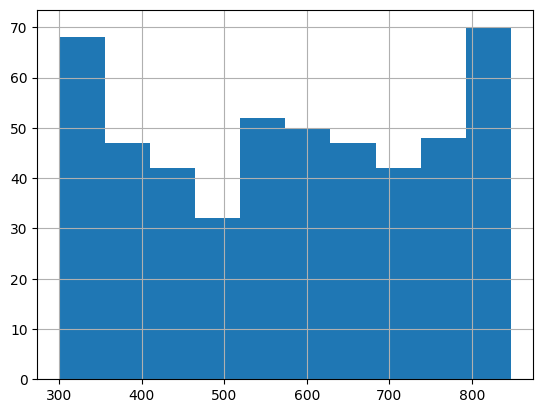

In [ ]:
df['Credit_Score'].hist()
plt.show()

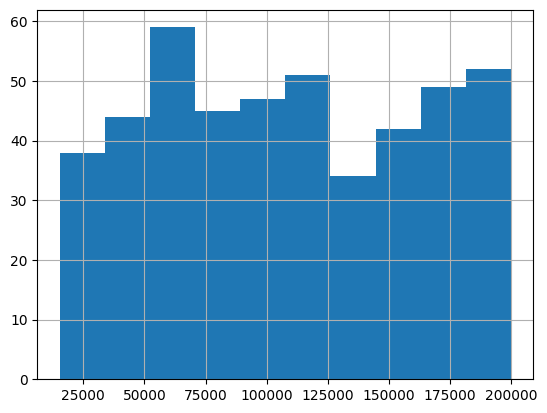

In [ ]:
df['Income'].hist()
plt.show()

In [ ]:
df['Income'].fillna(df['Income'].median(), inplace=True)

In [ ]:
df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)

/tmp/ipykernel_2071/2428711516.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)


In [ ]:
df['Loan_Balance'].fillna(df['Loan_Balance'].median(), inplace=True)

/tmp/ipykernel_2071/3211639815.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Balance'].fillna(df['Loan_Balance'].median(), inplace=True)


In [ ]:
df.shape


(500, 19)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Credit_Score,0
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,0
Debt_to_Income_Ratio,0
Employment_Status,0


In [ ]:
df['Delinquent_Account'].value_counts()

,count
Delinquent_Account,
0,420
1,80


In [13]:
df.groupby('Delinquent_Account')[
    ['Credit_Utilization',
     'Credit_Score',
     'Missed_Payments',
     'Debt_to_Income_Ratio']
].mean()

,Credit_Utilization,Credit_Score,Missed_Payments,Debt_to_Income_Ratio
Delinquent_Account,,,,
0,0.488505,575.145933,2.990476,0.297445
1,0.506887,591.150000,2.850000,0.306301


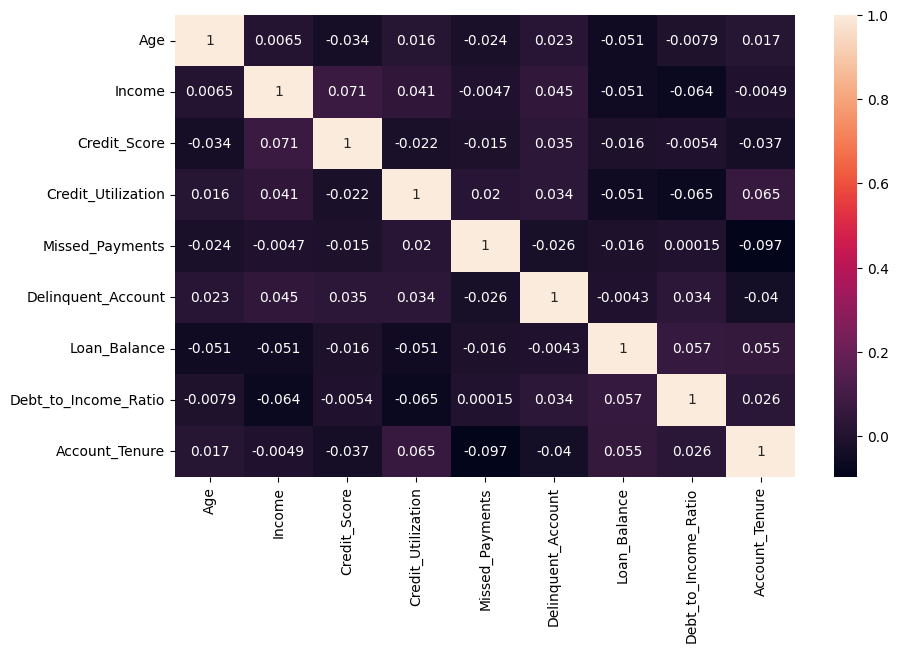

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()